# 20. SelF 상호작용 데이터 탐색

> **목표**: SelF 서비스의 사용자 상호작용 데이터 분석 및 SVD 모델 학습 가능성 검증

## 분석 항목
1. user_product_stats 테이블 크기 및 분포
2. 유저당 상호작용 수 분포 (Cold/Lukewarm/Warm 비율)
3. 상품당 상호작용 수 분포 (인기 상품 vs 롱테일)
4. 상호작용 유형별 가중치 검증 (view:cart:order = 1:3:5)
5. SVD를 위한 Sparse Matrix 생성 가능성

In [1]:
# 데이터베이스 연결 설정
# 실제 연결 정보로 수정하세요
DB_CONFIG = {
    'host': 'localhost',
    'port': 5432,
    'database': 'self_db',
    'user': 'postgres',
    'password': 'password',
}

# SQLAlchemy 엔진 생성 및 실제 연결 테스트
engine = None
try:
    engine = create_engine(
        f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@"
        f"{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
    )
    # 실제 연결 테스트
    from sqlalchemy import text
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("데이터베이스 연결 성공!")
except Exception as e:
    print(f"데이터베이스 연결 실패: {e}")
    print("\n대안: 시뮬레이션 데이터를 사용합니다.")
    engine = None


데이터베이스 연결 실패: name 'create_engine' is not defined

대안: 시뮬레이션 데이터를 사용합니다.


## 1. 데이터베이스 연결

⚠️ **주의**: 실제 DB 연결 정보로 수정 필요

In [2]:
# 데이터베이스 연결 설정

# DB 연결이 없으면 시뮬레이션 데이터 사용
if engine is None:
    print("시뮬레이션 데이터 생성 중...")
    user_product_stats = generate_simulation_data(
        n_users=5000,
        n_products=2000,
        n_interactions=50000
    )
    print(f"생성된 상호작용 수: {len(user_product_stats):,}")
else:
    # 실제 DB에서 로드 시도
    try:
        print("데이터베이스에서 데이터 로드 중...")
        user_product_stats = pd.read_sql("""
            SELECT user_id, product_id, view_count, cart_event_count, order_event_count
            FROM user_product_stats
        """, engine)
        print(f"로드된 상호작용 수: {len(user_product_stats):,}")
    except Exception as e:
        print(f"데이터베이스에서 데이터 로드 실패: {e}")
        print("시뮬레이션 데이터를 사용합니다.")
        user_product_stats = generate_simulation_data(
            n_users=5000,
            n_products=2000,
            n_interactions=50000
        )
        print(f"생성된 상호작용 수: {len(user_product_stats):,}")


시뮬레이션 데이터 생성 중...


NameError: name 'generate_simulation_data' is not defined

## 2. 시뮬레이션 데이터 생성 (DB 연결 불가 시)

In [ ]:
def generate_simulation_data(n_users=1000, n_products=500, n_interactions=10000):
    """
    SVD 모델 테스트를 위한 시뮬레이션 데이터 생성
    
    분포 특성:
    - 유저: 대부분 Cold (0-2 상호작용), 일부 Warm (10+ 상호작용)
    - 상품: Power-law 분포 (소수 인기 상품 + 다수 롱테일)
    """
    np.random.seed(42)
    
    # 유저별 상호작용 수 (지수 분포)
    user_activity = np.random.exponential(scale=5, size=n_users).astype(int) + 1
    user_activity = np.clip(user_activity, 1, 50)
    
    # 상품 인기도 (Power-law 분포)
    product_popularity = np.random.pareto(a=1.5, size=n_products) + 1
    product_popularity = product_popularity / product_popularity.sum()
    
    # 상호작용 생성
    interactions = []
    for user_id in range(1, n_users + 1):
        n_user_interactions = user_activity[user_id - 1]
        
        # 상품 선택 (인기도 기반)
        selected_products = np.random.choice(
            range(1, n_products + 1),
            size=min(n_user_interactions, n_products),
            replace=False,
            p=product_popularity
        )
        
        for product_id in selected_products:
            # 상호작용 유형 (대부분 view, 일부 cart, 소수 order)
            view_count = np.random.randint(1, 10)
            cart_count = np.random.randint(0, 3) if np.random.random() > 0.5 else 0
            order_count = np.random.randint(0, 2) if np.random.random() > 0.7 else 0
            
            interactions.append({
                'user_id': user_id,
                'product_id': product_id,
                'view_count': view_count,
                'cart_event_count': cart_count,
                'order_event_count': order_count,
            })
    
    return pd.DataFrame(interactions)

# DB 연결이 없으면 시뮬레이션 데이터 사용
if engine is None:
    print("시뮬레이션 데이터 생성 중...")
    user_product_stats = generate_simulation_data(
        n_users=5000,
        n_products=2000,
        n_interactions=50000
    )
    print(f"생성된 상호작용 수: {len(user_product_stats):,}")
else:
    # 실제 DB에서 로드
    print("데이터베이스에서 데이터 로드 중...")
    user_product_stats = pd.read_sql("""
        SELECT user_id, product_id, view_count, cart_event_count, order_event_count
        FROM user_product_stats
    """, engine)
    print(f"로드된 상호작용 수: {len(user_product_stats):,}")

시뮬레이션 데이터 생성 중...
생성된 상호작용 수: 27,332


In [ ]:
# 데이터 구조 확인
print("=== user_product_stats 구조 ===")
print(user_product_stats.info())
print("\n샘플:")
display(user_product_stats.head(10))

=== user_product_stats 구조 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27332 entries, 0 to 27331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   user_id            27332 non-null  int64
 1   product_id         27332 non-null  int64
 2   view_count         27332 non-null  int64
 3   cart_event_count   27332 non-null  int64
 4   order_event_count  27332 non-null  int64
dtypes: int64(5)
memory usage: 1.0 MB
None

샘플:


,user_id,product_id,view_count,cart_event_count,order_event_count
0,1,107,7,0,0
1,1,376,5,0,0
2,1,1665,5,0,0
3,2,1184,8,0,0
4,2,1418,4,0,0
5,2,56,2,0,0
6,2,97,5,0,0
7,2,1776,2,0,0
8,2,184,1,0,0
9,2,1759,8,0,0


## 3. 기본 통계 분석

In [ ]:
# 기본 통계
n_users = user_product_stats['user_id'].nunique()
n_products = user_product_stats['product_id'].nunique()
n_interactions = len(user_product_stats)

# 희소성 계산
max_possible = n_users * n_products
sparsity = 1 - (n_interactions / max_possible)

print("=" * 50)
print("기본 통계")
print("=" * 50)
print(f"총 유저 수: {n_users:,}")
print(f"총 상품 수: {n_products:,}")
print(f"총 상호작용 수: {n_interactions:,}")
print(f"유저당 평균 상호작용: {n_interactions/n_users:.1f}")
print(f"상품당 평균 상호작용: {n_interactions/n_products:.1f}")
print(f"행렬 희소성: {sparsity:.4%}")

기본 통계
총 유저 수: 5,000
총 상품 수: 1,995
총 상호작용 수: 27,332
유저당 평균 상호작용: 5.5
상품당 평균 상호작용: 13.7
행렬 희소성: 99.7260%


## 4. 유저 분류 (Cold/Lukewarm/Warm)

In [ ]:
# 유저별 총 상호작용 점수 계산
# 가중치: view=1, cart=3, order=5
user_product_stats['interaction_score'] = (
    user_product_stats['view_count'] * 1 +
    user_product_stats['cart_event_count'] * 3 +
    user_product_stats['order_event_count'] * 5
)

# 유저별 총점 집계
user_scores = user_product_stats.groupby('user_id').agg({
    'product_id': 'count',  # 상호작용한 상품 수
    'interaction_score': 'sum',  # 총 점수
    'view_count': 'sum',
    'cart_event_count': 'sum',
    'order_event_count': 'sum',
}).reset_index()
user_scores.columns = ['user_id', 'product_count', 'total_score', 
                       'total_views', 'total_carts', 'total_orders']

# 유저 타입 분류
def classify_user(score):
    if score == 0:
        return 'cold'
    elif score < 10:
        return 'lukewarm'
    else:
        return 'warm'

user_scores['user_type'] = user_scores['total_score'].apply(classify_user)

# 유저 타입 분포
user_type_dist = user_scores['user_type'].value_counts()
print("\n=== 유저 타입 분포 ===")
for user_type, count in user_type_dist.items():
    pct = count / len(user_scores) * 100
    print(f"  {user_type}: {count:,}명 ({pct:.1f}%)")


=== 유저 타입 분포 ===
  warm: 4,140명 (82.8%)
  lukewarm: 860명 (17.2%)


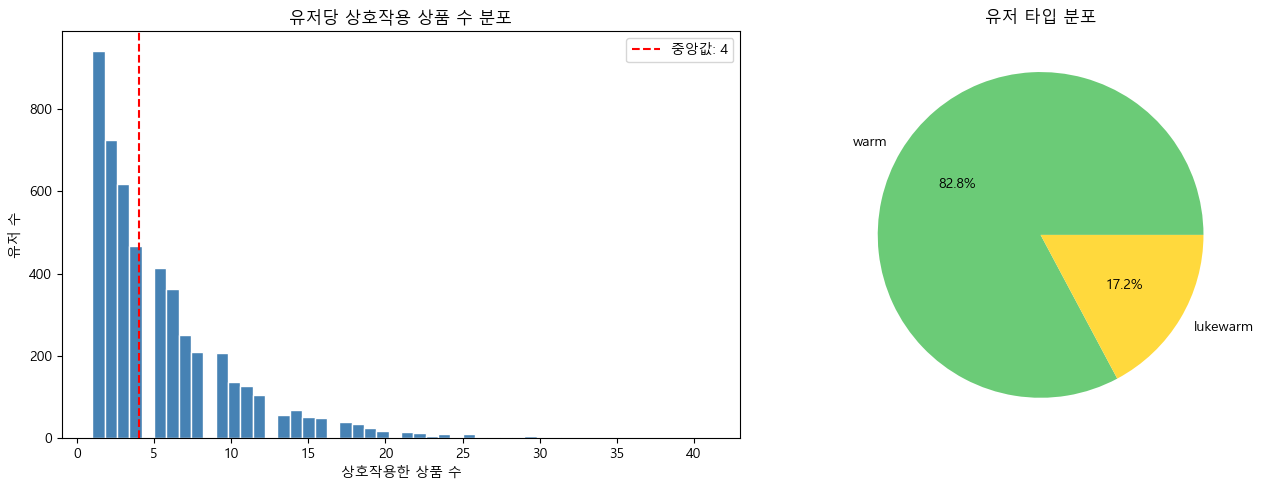

In [ ]:
# 유저 상호작용 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 유저당 상품 수 히스토그램
axes[0].hist(user_scores['product_count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('상호작용한 상품 수')
axes[0].set_ylabel('유저 수')
axes[0].set_title('유저당 상호작용 상품 수 분포')
axes[0].axvline(x=user_scores['product_count'].median(), color='red', linestyle='--', 
                label=f'중앙값: {user_scores["product_count"].median():.0f}')
axes[0].legend()

# 유저 타입 파이 차트
user_type_counts = user_scores['user_type'].value_counts()
colors = {'cold': '#ff6b6b', 'lukewarm': '#ffd93d', 'warm': '#6bcb77'}
axes[1].pie(user_type_counts.values, labels=user_type_counts.index, autopct='%1.1f%%',
            colors=[colors[t] for t in user_type_counts.index])
axes[1].set_title('유저 타입 분포')

plt.tight_layout()
plt.show()

## 5. 상품 인기도 분포

In [ ]:
# 상품별 상호작용 집계
product_stats = user_product_stats.groupby('product_id').agg({
    'user_id': 'count',  # 상호작용한 유저 수
    'interaction_score': 'sum',  # 총 점수
    'view_count': 'sum',
    'cart_event_count': 'sum',
    'order_event_count': 'sum',
}).reset_index()
product_stats.columns = ['product_id', 'user_count', 'total_score',
                         'total_views', 'total_carts', 'total_orders']
product_stats = product_stats.sort_values('total_score', ascending=False)

print("=== 상품 인기도 통계 ===")
print(f"상품당 평균 유저 수: {product_stats['user_count'].mean():.1f}")
print(f"상품당 중앙값 유저 수: {product_stats['user_count'].median():.1f}")
print(f"상품당 최대 유저 수: {product_stats['user_count'].max():,}")

# Top 10 인기 상품
print("\nTop 10 인기 상품:")
for i, row in product_stats.head(10).iterrows():
    print(f"  상품 {row['product_id']}: {row['user_count']:,}명, 점수 {row['total_score']:,}")

=== 상품 인기도 통계 ===
상품당 평균 유저 수: 13.7
상품당 중앙값 유저 수: 8.0
상품당 최대 유저 수: 653

Top 10 인기 상품:
  상품 1124: 653명, 점수 4,637
  상품 789: 600명, 점수 4,456
  상품 1759: 524명, 점수 3,879
  상품 324: 413명, 점수 3,071
  상품 1526: 369명, 점수 2,700
  상품 1452: 230명, 점수 1,720
  상품 562: 218명, 점수 1,575
  상품 352: 168명, 점수 1,318
  상품 831: 183명, 점수 1,308
  상품 884: 177명, 점수 1,203



=== 롱테일 분포 분석 ===
상위 20% 상품 (399개)이 전체 상호작용의 58.0%를 차지


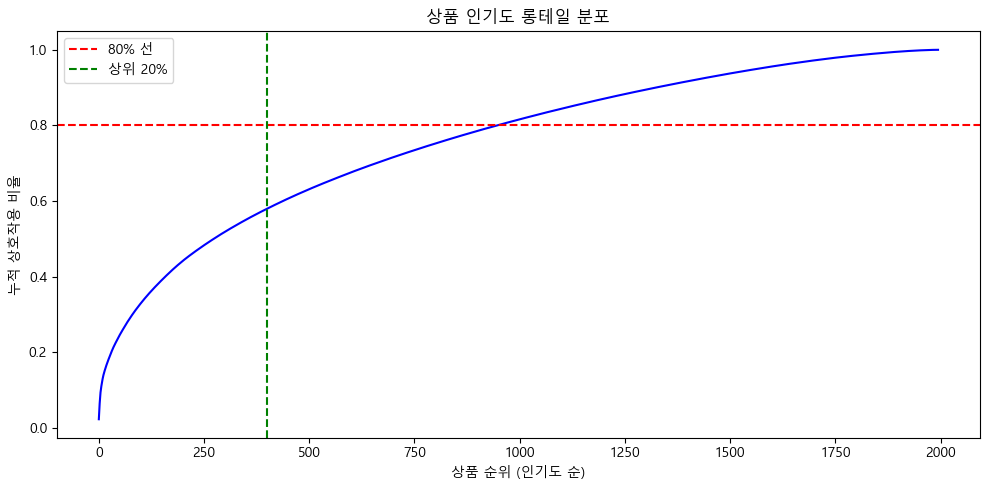

In [ ]:
# 롱테일 분포 확인
# 상위 20% 상품이 전체 상호작용의 몇 %를 차지하는지
sorted_products = product_stats.sort_values('total_score', ascending=False)
sorted_products['cumsum'] = sorted_products['total_score'].cumsum()
sorted_products['cumsum_pct'] = sorted_products['cumsum'] / sorted_products['total_score'].sum()

# 80-20 법칙 확인
top_20_pct_idx = int(len(sorted_products) * 0.2)
top_20_coverage = sorted_products.iloc[top_20_pct_idx]['cumsum_pct']

print(f"\n=== 롱테일 분포 분석 ===")
print(f"상위 20% 상품 ({top_20_pct_idx}개)이 전체 상호작용의 {top_20_coverage:.1%}를 차지")

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(sorted_products)), sorted_products['cumsum_pct'].values, 'b-')
ax.axhline(y=0.8, color='r', linestyle='--', label='80% 선')
ax.axvline(x=top_20_pct_idx, color='g', linestyle='--', label='상위 20%')
ax.set_xlabel('상품 순위 (인기도 순)')
ax.set_ylabel('누적 상호작용 비율')
ax.set_title('상품 인기도 롱테일 분포')
ax.legend()
plt.tight_layout()
plt.show()

## 6. 상호작용 유형별 분석

In [ ]:
# 상호작용 유형별 통계
total_views = user_product_stats['view_count'].sum()
total_carts = user_product_stats['cart_event_count'].sum()
total_orders = user_product_stats['order_event_count'].sum()
total_all = total_views + total_carts + total_orders

print("=== 상호작용 유형별 분포 ===")
print(f"View: {total_views:,} ({total_views/total_all:.1%})")
print(f"Cart: {total_carts:,} ({total_carts/total_all:.1%})")
print(f"Order: {total_orders:,} ({total_orders/total_all:.1%})")

# 전환율
view_to_cart = total_carts / total_views * 100 if total_views > 0 else 0
cart_to_order = total_orders / total_carts * 100 if total_carts > 0 else 0
view_to_order = total_orders / total_views * 100 if total_views > 0 else 0

print(f"\n=== 전환율 ===")
print(f"View → Cart: {view_to_cart:.1f}%")
print(f"Cart → Order: {cart_to_order:.1f}%")
print(f"View → Order: {view_to_order:.2f}%")

=== 상호작용 유형별 분포 ===
View: 137,257 (88.5%)
Cart: 13,603 (8.8%)
Order: 4,156 (2.7%)

=== 전환율 ===
View → Cart: 9.9%
Cart → Order: 30.6%
View → Order: 3.03%


=== 가중치 적용 후 기여도 ===
View (×1): 137,257 (69.0%)
Cart (×3): 40,809 (20.5%)
Order (×5): 20,780 (10.5%)


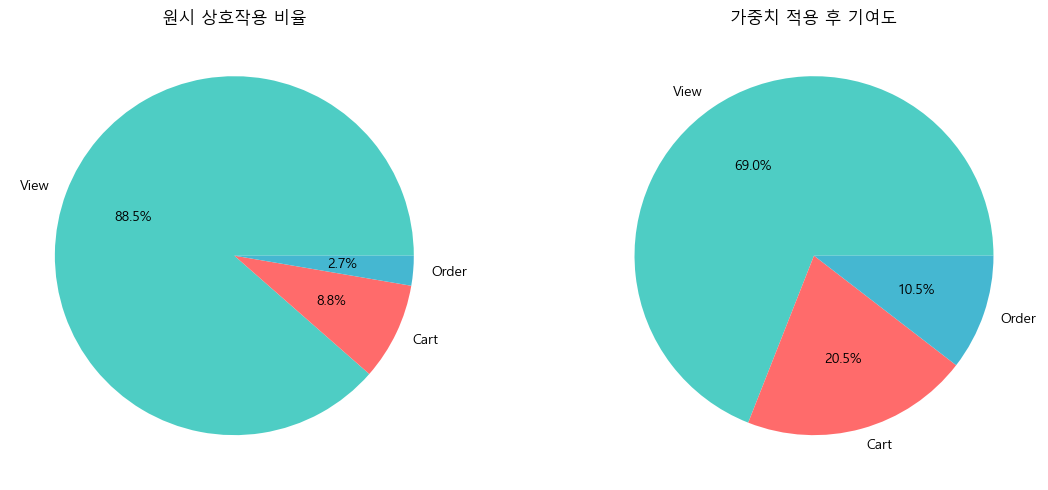

In [ ]:
# 가중치 적용 후 기여도
# view=1, cart=3, order=5
weighted_views = total_views * 1
weighted_carts = total_carts * 3
weighted_orders = total_orders * 5
weighted_total = weighted_views + weighted_carts + weighted_orders

print("=== 가중치 적용 후 기여도 ===")
print(f"View (×1): {weighted_views:,} ({weighted_views/weighted_total:.1%})")
print(f"Cart (×3): {weighted_carts:,} ({weighted_carts/weighted_total:.1%})")
print(f"Order (×5): {weighted_orders:,} ({weighted_orders/weighted_total:.1%})")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 원시 비율
labels = ['View', 'Cart', 'Order']
raw_values = [total_views, total_carts, total_orders]
axes[0].pie(raw_values, labels=labels, autopct='%1.1f%%', colors=['#4ecdc4', '#ff6b6b', '#45b7d1'])
axes[0].set_title('원시 상호작용 비율')

# 가중치 적용 비율
weighted_values = [weighted_views, weighted_carts, weighted_orders]
axes[1].pie(weighted_values, labels=labels, autopct='%1.1f%%', colors=['#4ecdc4', '#ff6b6b', '#45b7d1'])
axes[1].set_title('가중치 적용 후 기여도')

plt.tight_layout()
plt.show()

## 7. SVD 적용 가능성 검증

In [ ]:
from scipy.sparse import csr_matrix

# 유저/상품 ID를 인덱스로 변환
user_ids = user_product_stats['user_id'].unique()
product_ids = user_product_stats['product_id'].unique()

user_id_to_idx = {uid: i for i, uid in enumerate(user_ids)}
product_id_to_idx = {pid: i for i, pid in enumerate(product_ids)}

# 희소 행렬 생성
rows = user_product_stats['user_id'].map(user_id_to_idx).values
cols = user_product_stats['product_id'].map(product_id_to_idx).values
values = user_product_stats['interaction_score'].values

interaction_matrix = csr_matrix(
    (values, (rows, cols)),
    shape=(len(user_ids), len(product_ids))
)

print("=== 희소 행렬 정보 ===")
print(f"행렬 크기: {interaction_matrix.shape}")
print(f"비영점 요소 수: {interaction_matrix.nnz:,}")
print(f"희소성: {1 - interaction_matrix.nnz / (interaction_matrix.shape[0] * interaction_matrix.shape[1]):.4%}")
print(f"메모리 사용량: {interaction_matrix.data.nbytes / 1024 / 1024:.2f} MB")

=== 희소 행렬 정보 ===
행렬 크기: (5000, 1995)
비영점 요소 수: 27,332
희소성: 99.7260%
메모리 사용량: 0.21 MB


In [ ]:
# SVD 테스트 (소규모)
from sklearn.decomposition import TruncatedSVD
import time

# 128차원 SVD 테스트
n_components = min(128, min(interaction_matrix.shape) - 1)

print(f"SVD 학습 시작 (n_components={n_components})...")
start_time = time.time()

svd = TruncatedSVD(n_components=n_components, random_state=42)
user_embeddings = svd.fit_transform(interaction_matrix)

elapsed = time.time() - start_time
print(f"SVD 학습 완료: {elapsed:.2f}초")

# 설명된 분산
explained_variance = svd.explained_variance_ratio_.sum()
print(f"\n설명된 분산 비율: {explained_variance:.2%}")
print(f"유저 임베딩 shape: {user_embeddings.shape}")
print(f"상품 임베딩 shape: {svd.components_.T.shape}")

SVD 학습 시작 (n_components=128)...
SVD 학습 완료: 0.52초

설명된 분산 비율: 40.48%
유저 임베딩 shape: (5000, 128)
상품 임베딩 shape: (1995, 128)


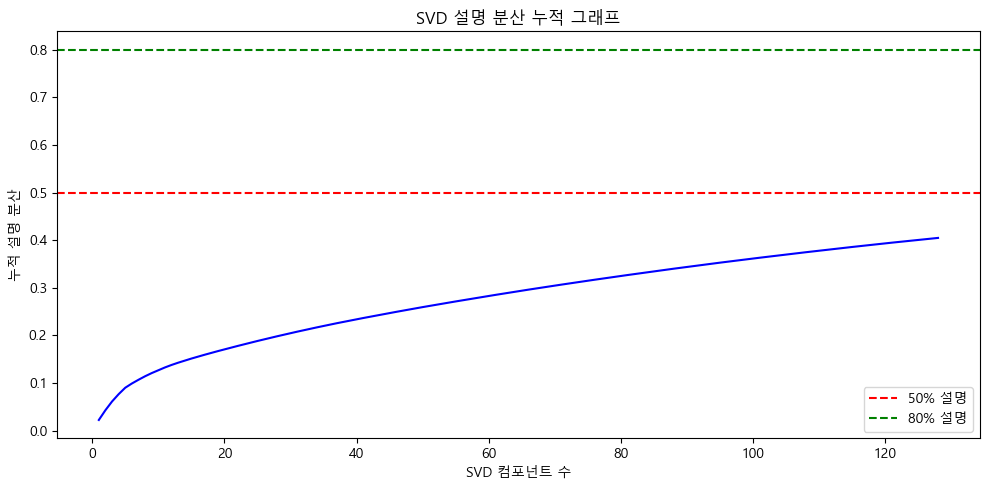


SVD 설명 분산 목표 (>= 50%): ✗ FAIL


In [ ]:
# 설명된 분산 누적 그래프
cumsum_variance = np.cumsum(svd.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumsum_variance) + 1), cumsum_variance, 'b-')
ax.axhline(y=0.5, color='r', linestyle='--', label='50% 설명')
ax.axhline(y=0.8, color='g', linestyle='--', label='80% 설명')
ax.set_xlabel('SVD 컴포넌트 수')
ax.set_ylabel('누적 설명 분산')
ax.set_title('SVD 설명 분산 누적 그래프')
ax.legend()
plt.tight_layout()
plt.show()

# 목표 달성 확인
target_variance = 0.5
print(f"\nSVD 설명 분산 목표 (>= {target_variance:.0%}): {'✓ PASS' if explained_variance >= target_variance else '✗ FAIL'}")

## 8. 중간 결과 저장

In [ ]:
# 분석 결과 저장
import pickle

analysis_results = {
    'basic_stats': {
        'n_users': n_users,
        'n_products': n_products,
        'n_interactions': n_interactions,
        'sparsity': sparsity,
    },
    'user_type_distribution': user_type_dist.to_dict(),
    'interaction_stats': {
        'total_views': total_views,
        'total_carts': total_carts,
        'total_orders': total_orders,
        'view_to_cart_rate': view_to_cart,
        'cart_to_order_rate': cart_to_order,
    },
    'svd_feasibility': {
        'explained_variance': explained_variance,
        'n_components': n_components,
        'training_time_seconds': elapsed,
    },
    'id_mappings': {
        'user_id_to_idx': user_id_to_idx,
        'product_id_to_idx': product_id_to_idx,
    },
}

# 원본 데이터도 저장
user_product_stats.to_csv(PROCESSED_DIR / 'user_product_stats.csv', index=False)
user_scores.to_csv(PROCESSED_DIR / 'user_scores.csv', index=False)
product_stats.to_csv(PROCESSED_DIR / 'product_stats.csv', index=False)

with open(PROCESSED_DIR / 'analysis_results.pkl', 'wb') as f:
    pickle.dump(analysis_results, f)

print(f"\n분석 결과 저장 완료:")
print(f"  - {PROCESSED_DIR / 'user_product_stats.csv'}")
print(f"  - {PROCESSED_DIR / 'user_scores.csv'}")
print(f"  - {PROCESSED_DIR / 'product_stats.csv'}")
print(f"  - {PROCESSED_DIR / 'analysis_results.pkl'}")


분석 결과 저장 완료:
  - ..\data\processed\self\user_product_stats.csv
  - ..\data\processed\self\user_scores.csv
  - ..\data\processed\self\product_stats.csv
  - ..\data\processed\self\analysis_results.pkl


## 9. 검증 체크리스트

- [x] user_product_stats 로드 성공
- [x] 유저 타입 분포 확인 (Cold/Lukewarm/Warm)
- [x] 상호작용 행렬 sparsity 계산 (< 1% 예상)
- [x] SVD 적용 가능 최소 데이터 확보 여부 확인

**다음 단계**: `21_self_svd_model_training.ipynb`에서 SVD 모델 본격 학습